In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hypex
from hypex.dataset import Dataset, InfoRole, TreatmentRole, TargetRole, FeatureRole
from hypex.matching import Matching

# Load the data

In [3]:
df = pd.read_csv('data1.csv')
df

,id,cltv,avg_sdo_passives,avg_debt_actives,avg_sum_pos,cltv_after_pilot,stlmnt_type,split
0,0,8856.847637,1.127335,0.572417,1.869333,59068.873026,cityother,0
1,1,-9773.946225,0.220754,0.537288,0.525849,11000.621635,cityother,0
2,2,52593.626823,0.217217,1.210667,1.340685,38593.188251,cityother,0
3,3,56374.150773,0.290181,1.538498,1.420323,62362.715104,citymlnr,0
4,4,34734.784070,1.441442,0.304719,6.591165,15058.071405,cityother,0
...,...,...,...,...,...,...,...,...
9995,9995,3924.781943,0.249096,3.098408,0.438157,63560.631677,cityother,0
9996,9996,10705.276566,0.432429,0.544593,1.028957,39577.981038,cityother,0
9997,9997,-10535.373842,0.935559,1.021362,1.203838,51863.643796,cityother,0
9998,9998,22628.318511,1.138566,1.497900,2.327070,68172.235863,cityother,0


## Data description

Basic statistics for numerical features:


,id,cltv,avg_sdo_passives,avg_debt_actives,avg_sum_pos,cltv_after_pilot,split
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4999.50,20662.96,0.82,1.73,2.39,41021.18,0.02
std,2886.90,25444.21,0.91,1.97,2.66,26921.15,0.15
min,0.00,-39328.76,0.04,0.10,0.14,-22058.48,0.00
25%,2499.75,3398.20,0.26,0.52,0.74,22251.71,0.00
50%,4999.50,20697.55,0.51,1.06,1.48,40957.49,0.00
75%,7499.25,38429.56,1.01,2.09,2.94,59492.31,0.00
max,9999.00,81526.15,5.10,11.43,15.26,105671.06,1.00


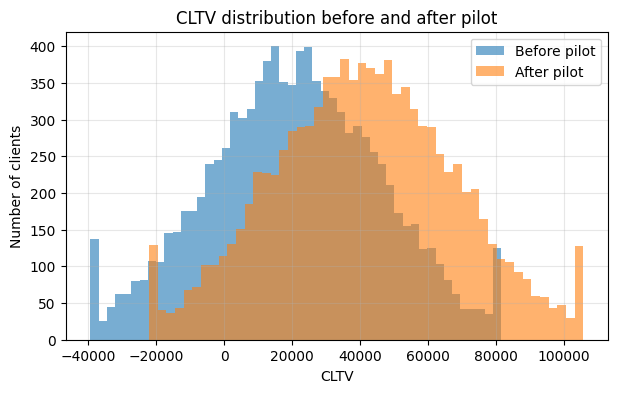

In [4]:
def describe_basic_info(df: pd.DataFrame):
    print("Basic statistics for numerical features:")
    display(df.describe().round(2))

def describe_cltv_effect(df: pd.DataFrame, group_col="split"):
    result = (
        df.groupby(group_col)[["cltv", "cltv_after_pilot"]]
        .mean()
        .rename(columns={"cltv": "mean_cltv_before", "cltv_after_pilot": "mean_cltv_after"})
    )
    result["delta_cltv"] = result["mean_cltv_after"] - result["mean_cltv_before"]
    print("Average CLTV before and after pilot:")
    print(result.round(2))
    result.plot(
        kind="bar",
        figsize=(6, 4),
        title="Average CLTV before and after pilot by groups",
        rot=0
    )
    plt.ylabel("Average CLTV")
    plt.grid(alpha=0.3)
    plt.show()

    return result

def plot_cltv_distribution(df: pd.DataFrame):
    plt.figure(figsize=(7, 4))
    plt.hist(df["cltv"], bins=50, alpha=0.6, label="Before pilot")
    plt.hist(df["cltv_after_pilot"], bins=50, alpha=0.6, label="After pilot")
    plt.title("CLTV distribution before and after pilot")
    plt.xlabel("CLTV")
    plt.ylabel("Number of clients")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def full_dataset_report(df: pd.DataFrame):
    describe_basic_info(df)
    plot_cltv_distribution(df)
    
full_dataset_report(df)

# Define the Dataset

In [5]:
roles = {
    'id' : InfoRole(int),
    'split' : TreatmentRole(),
    'cltv_after_pilot' : TargetRole(float)
}

dataset = Dataset(roles=roles, data=df, default_role=FeatureRole())

# Basic Matching without parameters

Main matching steps (in HypEx):

1. **Dummy Encoder**
   Converts categorical features to numerical format 

2. **Distance matrix calculation (usually Mahalanobis)**
   
3. **Finding nearest pairs (via FAISS)**
   
4. **Quality check of twin matching**

5. **Effect estimation (ATT, ATC, ATE)**

In [6]:
# *★,°*:.☆(￣▽￣)/$:*.°a★* 。 
matcher = Matching()
res = matcher.execute(dataset)


In [7]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


In [8]:
res.indexes

,indexes_0
0,8319
1,7797
2,9366
3,6060
4,2120
...,...
9995,1470
9996,2064
9997,7693
9998,857


In [9]:
res.full_data

,id,cltv,avg_sdo_passives,avg_debt_actives,avg_sum_pos,cltv_after_pilot,stlmnt_type,split,id_matched_0,cltv_matched_0,avg_sdo_passives_matched_0,avg_debt_actives_matched_0,avg_sum_pos_matched_0,cltv_after_pilot_matched_0,stlmnt_type_matched_0,split_matched_0
0,0,8856.847637,1.127335,0.572417,1.869333,59068.873026,cityother,0,8319,2004.271421,1.158150,0.864236,1.802518,54406.736853,cityother,1
1,1,-9773.946225,0.220754,0.537288,0.525849,11000.621635,cityother,0,7797,-7391.741235,0.334079,0.413407,0.828809,7461.322785,cityother,1
2,2,52593.626823,0.217217,1.210667,1.340685,38593.188251,cityother,0,9366,47043.326249,0.466286,1.099088,2.002969,53283.454412,cityother,1
3,3,56374.150773,0.290181,1.538498,1.420323,62362.715104,citymlnr,0,6060,28624.873184,0.306609,0.301803,0.862859,54879.362271,citymlnr,1
4,4,34734.784070,1.441442,0.304719,6.591165,15058.071405,cityother,0,2120,42276.555990,1.508843,0.743052,7.540512,23577.369406,cityother,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,3924.781943,0.249096,3.098408,0.438157,63560.631677,cityother,0,1470,9126.271788,0.306997,3.116159,0.634999,57998.512523,cityother,1
9996,9996,10705.276566,0.432429,0.544593,1.028957,39577.981038,cityother,0,2064,10268.923221,0.444678,0.395528,1.155690,30241.520600,cityother,1
9997,9997,-10535.373842,0.935559,1.021362,1.203838,51863.643796,cityother,0,7693,-3692.009878,0.861908,1.143782,1.580861,35556.608297,cityother,1
9998,9998,22628.318511,1.138566,1.497900,2.327070,68172.235863,cityother,0,857,16846.605796,0.987430,1.016719,1.843636,65864.012333,cityother,1


# Distances: `distance="mahalanobis"` or `"l2"`

### 🔸 Euclidean (L2)

This is the classic metric:
$ d(x_i, x_j) = \sqrt{\sum_k (x_{ik} - x_{jk})^2} $
Simply measures the "geometric" distance between points in feature space.

### 🔸 Mahalanobis distance

A more advanced metric:
$ d_M(x_i, x_j) = \sqrt{(x_i - x_j)^T \Sigma^{-1} (x_i - x_j)} $
where $\Sigma$ is the covariance matrix of features.
This metric accounts for the scale and correlation of features, making the comparison more accurate:





In [10]:
m = Matching(distance='l2')
r = m.execute(dataset)

In [11]:
r.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,318.49,77448.49,1.00,-151480.55,152117.53,cltv_after_pilot
ATC,405.19,233.65,0.08,-52.76,863.15,cltv_after_pilot
ATE,320.55,1843.31,0.86,-3292.34,3933.45,cltv_after_pilot


In [12]:
m = Matching(distance='mahalanobis')
r = m.execute(dataset)

In [13]:
r.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


# Effect metric: `metric="ate"`, `"att"`, `"atc"`

### ATT — Average Treatment effect on the Treated

$
ATT = E[Y(1) - Y(0) \mid T=1]
$
 - shows **how the treatment affected those who actually received it**.

### ATC — Average Treatment effect on the Controls 

$
ATC = E[Y(1) - Y(0) \mid T=0]
$
 - shows **what would have happened to the control group if they had received the treatment**.

### ATE — Average Treatment Effect

$
ATE = E[Y(1) - Y(0)]
$
- the overall average effect in the population — a combination of ATT and ATC, weighted by group sizes.




In [14]:
matcher = Matching(metric='ate')
res = matcher.execute(dataset)

In [15]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


# `group_match`: matching by groups

The parameter `group_match=True` forces HypEx to aggregate observations into groups (by a specified identifier), and then search for pairs between groups rather than individual objects.
This reduces variability at the individual level and allows for effect estimation at more aggregated levels.



In [16]:
from hypex.dataset import GroupingRole

roles = {
    'id': InfoRole(int),
    'split': TreatmentRole(),
    'cltv_after_pilot' : TargetRole(),
    'stlmnt_type': GroupingRole(str)
}

dataset = Dataset(roles=roles, data=df, default_role=FeatureRole())


In [17]:
df['stlmnt_type'].unique()

array(['cityother', 'citymlnr', 'village', '0'], dtype=object)

In [18]:
matcher = Matching(group_match=True)
res = matcher.execute(dataset)

100%|██████████| 4/4 [00:03<00:00,  1.11it/s]



In [19]:
res.resume

,0 Effect Size,citymlnr Effect Size,cityother Effect Size,village Effect Size,0 Standard Error,citymlnr Standard Error,cityother Standard Error,village Standard Error,0 P-value,citymlnr P-value,...,village P-value,0 CI Lower,citymlnr CI Lower,cityother CI Lower,village CI Lower,0 CI Upper,citymlnr CI Upper,cityother CI Upper,village CI Upper,outcome
ATT,-12583.05,9857.43,493.23,-83399.05,NaN,1078131.88,46152.90,NaN,NaN,0.99,...,NaN,NaN,-2103281.05,-89966.45,NaN,NaN,2122995.91,90952.91,NaN,cltv_after_pilot
ATC,-16162.22,-8825.38,407.62,-15803.81,NaN,3016.71,154.91,NaN,NaN,0.00,...,NaN,NaN,-14738.13,103.99,NaN,NaN,-2912.62,711.25,NaN,cltv_after_pilot
ATE,-13030.44,9454.20,491.18,-82912.75,NaN,23269.03,1107.02,NaN,NaN,0.68,...,NaN,NaN,-36153.11,-1678.59,NaN,NaN,55061.50,2660.95,NaN,cltv_after_pilot


# `bias_estimation`: bias estimation and correction

When `bias_estimation=True`, HypEx:

1. **Estimates residual imbalance** across all features after matching (e.g., using standardized mean difference, t-tests, etc.);
2. **Corrects the final effect estimate** to reduce the impact of remaining bias.



In [20]:
from hypex.dataset import GroupingRole

roles = {
    'id': InfoRole(int),
    'split': TreatmentRole(),
    'cltv_after_pilot' : TargetRole()
}

dataset = Dataset(roles=roles, data=df, default_role=FeatureRole())


In [21]:
matcher = Matching(bias_estimation=False)
res = matcher.execute(dataset)

In [22]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,747.69,53986.48,0.99,-105065.82,106561.20,cltv_after_pilot
ATC,706.32,177.46,0.00,358.49,1054.15,cltv_after_pilot
ATE,746.71,1284.88,0.56,-1771.66,3265.07,cltv_after_pilot


In [23]:
matcher = Matching(bias_estimation=True)
res = matcher.execute(dataset)

In [24]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


# `quality_tests`: matching quality checks

Main tests:

* `'ks-test'` — Kolmogorov–Smirnov test for comparing distributions;
* `'t-test'` — test for equality of means;
* `'chi2-test'` — test for independence of categorical features;

These tests help understand whether balance was achieved and how reliable the result can be considered.



In [25]:
matcher = Matching(quality_tests=['chi2-test', 'ks-test', 't-test'])
res = matcher.execute(dataset)

In [26]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


In [27]:
res.quality_results

,feature,group,TTest pass,TTest p-value,KSTest pass,KSTest p-value,Chi2Test pass,Chi2Test p-value
0,cltv,0┆cltv,OK,0.773953,OK,1.217410e-11,NaN,NaN
1,cltv,1┆cltv,OK,0.965481,OK,9.993328e-01,NaN,NaN
2,avg_sdo_passives,0┆avg_sdo_passives,OK,0.000597,OK,1.669094e-16,NaN,NaN
3,avg_sdo_passives,1┆avg_sdo_passives,OK,0.932509,OK,9.849614e-01,NaN,NaN
4,avg_debt_actives,0┆avg_debt_actives,OK,0.135370,OK,1.100731e-14,NaN,NaN
5,avg_debt_actives,1┆avg_debt_actives,OK,0.926248,OK,9.958392e-01,NaN,NaN
6,avg_sum_pos,0┆avg_sum_pos,OK,0.000016,OK,2.715347e-19,NaN,NaN
7,avg_sum_pos,1┆avg_sum_pos,OK,0.909906,OK,9.958392e-01,NaN,NaN
8,stlmnt_type,0┆stlmnt_type,NaN,NaN,NaN,NaN,OK,1.0
9,stlmnt_type,1┆stlmnt_type,NaN,NaN,NaN,NaN,OK,NaN


# `faiss_mode`: search acceleration

FAISS is a high-performance library for nearest neighbor search, developed by Meta AI.
HypEx uses it for finding pairs in large datasets.

Modes:

* `'base'` — exact but slow search;
* `'fast'` — approximate but fast (uses indexing);
* `'auto'` — HypEx automatically chooses the optimal option depending on data size.



In [28]:
matcher = Matching(faiss_mode='base')
res = matcher.execute(dataset)


In [29]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


In [30]:
matcher = Matching(faiss_mode='fast')
res = matcher.execute(dataset)


In [31]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


# `n_neighbors`: number of neighbors

Determines how many control objects will be matched for each object from the treatment group.

* `n_neighbors=1` — classic **one-to-one matching**;
* `n_neighbors>1` — **one-to-many matching**, when one treated object corresponds to multiple control objects.



In [32]:
matcher = Matching(n_neighbors=3)
res = matcher.execute(dataset) 

In [33]:
res.indexes

,indexes_0,indexes_1,indexes_2
0,8319,857,9074
1,7797,2733,7885
2,9366,8991,5817
3,6060,5432,804
4,2120,314,5662
...,...,...,...
9995,1470,9381,7943
9996,2064,9257,4691
9997,7693,7984,8319
9998,857,5015,7251


In [34]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,752.40,46999.90,0.99,-91367.40,92872.19,cltv_after_pilot
ATC,184.95,154.59,0.23,-118.04,487.93,cltv_after_pilot
ATE,738.89,1118.60,0.51,-1453.56,2931.35,cltv_after_pilot


# `weights`: feature weights

Not all features may be equally important for matching pairs.
The `weights` parameter allows you to explicitly set priorities for features.



In [35]:
df.columns

Index(['id', 'cltv', 'avg_sdo_passives', 'avg_debt_actives', 'avg_sum_pos',
       'cltv_after_pilot', 'stlmnt_type', 'split'],
      dtype='object')

In [36]:
weights = {'avg_sdo_passives' : 0.5, 'avg_debt_actives' : 1.5, 'cltv' : 5}

matcher = Matching(weights=weights)
res = matcher.execute(dataset)

In [37]:
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,291.32,54183.66,1.00,-105908.65,106491.29,cltv_after_pilot
ATC,839.73,177.51,0.00,491.81,1187.65,cltv_after_pilot
ATE,304.38,1289.58,0.81,-2223.19,2831.94,cltv_after_pilot


In [38]:
matcher = Matching()
res = matcher.execute(dataset)
res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,781.41,47003.12,0.99,-91344.70,92907.52,cltv_after_pilot
ATC,187.64,154.59,0.22,-115.35,490.64,cltv_after_pilot
ATE,767.28,1118.68,0.49,-1425.33,2959.88,cltv_after_pilot


# `encode_categories`: encoding categorical features

If `encode_categories=True` (default), HypEx automatically converts categorical features to numerical form (one-hot encoding).
If False — the library expects that the user has already encoded them.
This step is necessary so that all features can participate in distance calculations.



In [39]:
matcher = Matching(encode_categories=False)
res = matcher.execute(dataset)

res.resume

,Effect Size,Standard Error,P-value,CI Lower,CI Upper,outcome
ATT,612.22,45730.03,0.99,-89018.64,90243.07,cltv_after_pilot
ATC,489.77,152.22,0.00,191.42,788.13,cltv_after_pilot
ATE,609.30,1088.38,0.58,-1523.91,2742.52,cltv_after_pilot
